Performing exploratory data analysis(EDA)i.e  on this Iris dataset
EDA is used to understand the data,identify patterns,detecting outliers and cleaning the data

In [1]:
from google.colab import files
uploaded=files.upload()

Saving Iris Dataset.csv to Iris Dataset.csv


In [5]:
import pandas as pd
df=pd.read_csv('Iris Dataset.csv')
# seeing the top of the dataset using head function
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
# seeing the bottom of the dataset using tail
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [9]:
#using the below functions to understand more about the data
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [ ]:
# removing the duplicate values in the dataset
df.dropna()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [12]:
# checking duplicate values
df.duplicated().sum()
df=df.drop_duplicates()

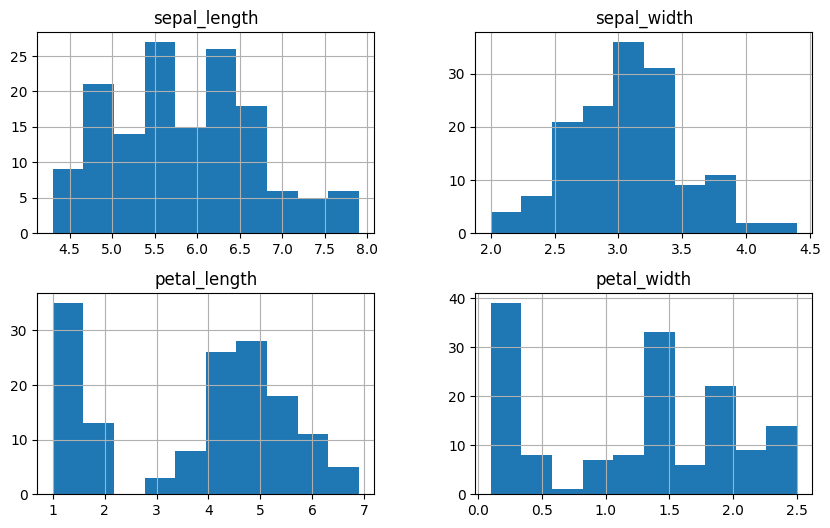

In [13]:
# univariate analysis
# numerical columns
import seaborn as sns
import matplotlib.pyplot as plt
df.hist(figsize=(10,6))
plt.show()

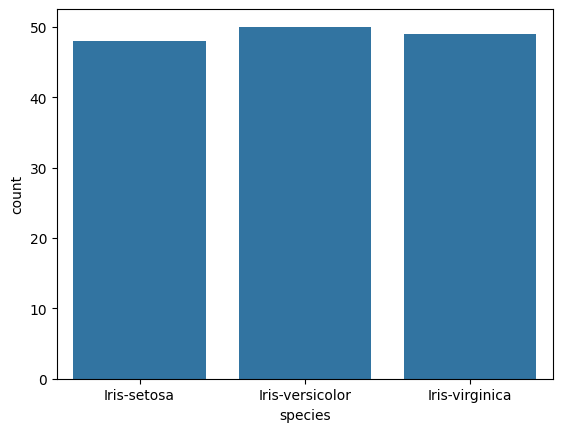

In [17]:
# to see the species,we woll form categorical columns
sns.countplot(x='species',data=df)
plt.show()

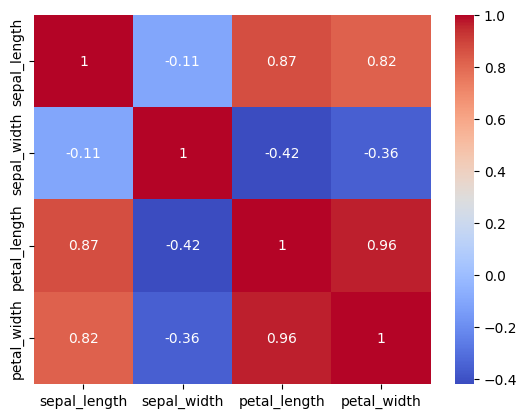

In [19]:
# Corelation heatmap
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap=
            'coolwarm')
plt.show()


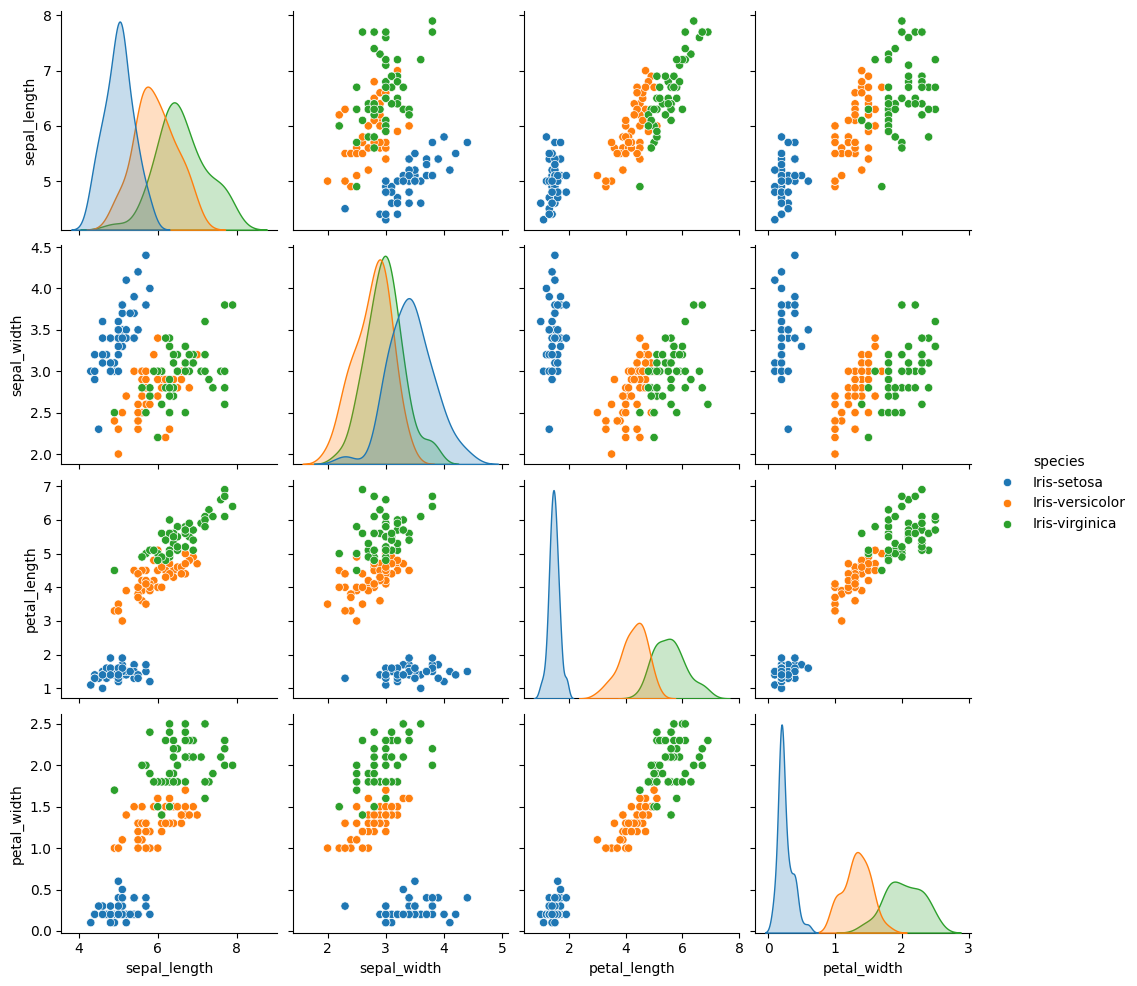

In [18]:
sns.pairplot(df,hue='species')
plt.show()

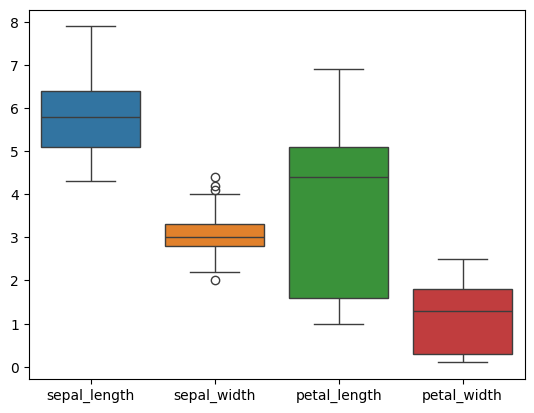

In [20]:
sns.boxplot(data=df)
plt.show()

Now we will perform logistic Regression

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [28]:
# preprocessing the data
X = df.drop('species', axis=1)
y = df['species']
le = LabelEncoder()
y = le.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [29]:
# train test and split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
# logistic regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
# knn
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [37]:
# decision tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [38]:
# comparing the three models
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.90      0.95        10
           2       0.90      1.00      0.95         9

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
 [[11  0  0]
 [ 0  9  1]
 [ 0  0  9]]


In [39]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.90      0.95        10
           2       0.90      1.00      0.95         9

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



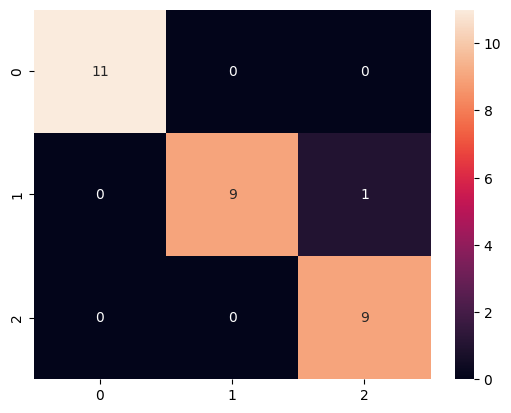

In [40]:
# confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True)
plt.show()

In [41]:
best_model = lr

In [42]:
import joblib

joblib.dump(best_model, "iris_model.pkl")

['iris_model.pkl']

In [43]:
model = joblib.load("iris_model.pkl")

sample = [[5.1, 3.5, 1.4, 0.2]]
sample = scaler.transform(sample)

prediction = model.predict(sample)
print(le.inverse_transform(prediction))

['Iris-setosa']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [46]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [47]:
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [48]:
from google.colab import files

files.download("iris_model.pkl")
files.download("scaler.pkl")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>